<a href="https://colab.research.google.com/github/madhu-80019/2420080019_ML/blob/main/ML_week12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import time
import warnings

warnings.filterwarnings('ignore')

In [2]:
# Part A: Data Loading and Preparation
print("=" * 50)
print("Part A: Data Loading and Preparation")
print("=" * 50)

# Load Fashion-MNIST dataset
print("Loading Fashion-MNIST dataset...")
fashion_mnist = fetch_openml('Fashion-MNIST', version=1, as_frame=False)
X, y = fashion_mnist.data, fashion_mnist.target.astype(int)

Part A: Data Loading and Preparation
Loading Fashion-MNIST dataset...


In [3]:
# For demonstration, we'll use 3000 samples to ensure faster computation
n_samples = 3000
np.random.seed(42)
indices = np.random.choice(X.shape[0], n_samples, replace=False)
X = X[indices]
y = y[indices]

print(f"Dataset shape: {X.shape}")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Class distribution: {np.bincount(y)}")

Dataset shape: (3000, 784)
Number of samples: 3000
Number of features: 784
Number of classes: 10
Class distribution: [300 288 293 296 288 307 311 298 289 330]


In [5]:
# Class names for Fashion-MNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat','Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Normalize pixel values
print("\nNormalizing pixel values...")
X_normalized = X / 255.0



Normalizing pixel values...


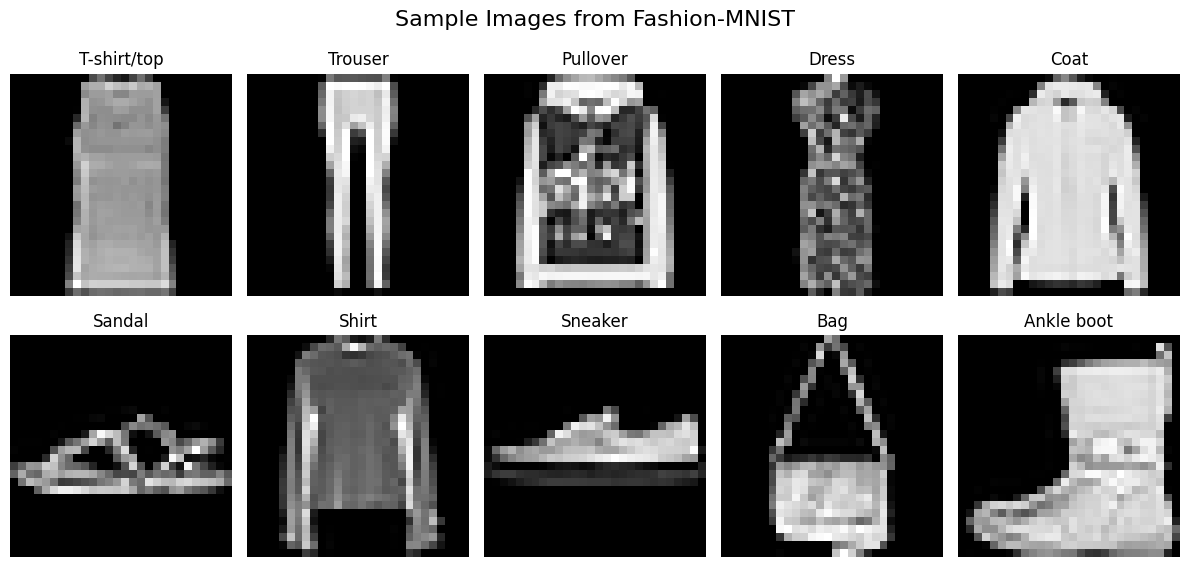

Sample images saved as 'fashion_mnist_samples.png'


In [7]:
# Visualize sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.ravel()

for i in range(10):
# Find first sample of each class
  idx = np.where(y == i)[0][0]
  axes[i].imshow(X[idx].reshape(28, 28), cmap='gray')
  axes[i].set_title(f'{class_names[i]}')
  axes[i].axis('off')

plt.suptitle('Sample Images from Fashion-MNIST', fontsize=16)
plt.tight_layout()
plt.savefig('fashion_mnist_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sample images saved as 'fashion_mnist_samples.png'")


In [8]:
# Part B: PCA Implementation
print("\n" + "=" * 50)
print("Part B: PCA Implementation")
print("=" * 50)


Part B: PCA Implementation


In [9]:
# Apply PCA
print("Applying PCA to reduce to 2 dimensions...")
start_time = time.time()
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_normalized)
pca_time = time.time() - start_time
print(f"PCA computation time: {pca_time:.2f} seconds")


Applying PCA to reduce to 2 dimensions...
PCA computation time: 0.83 seconds


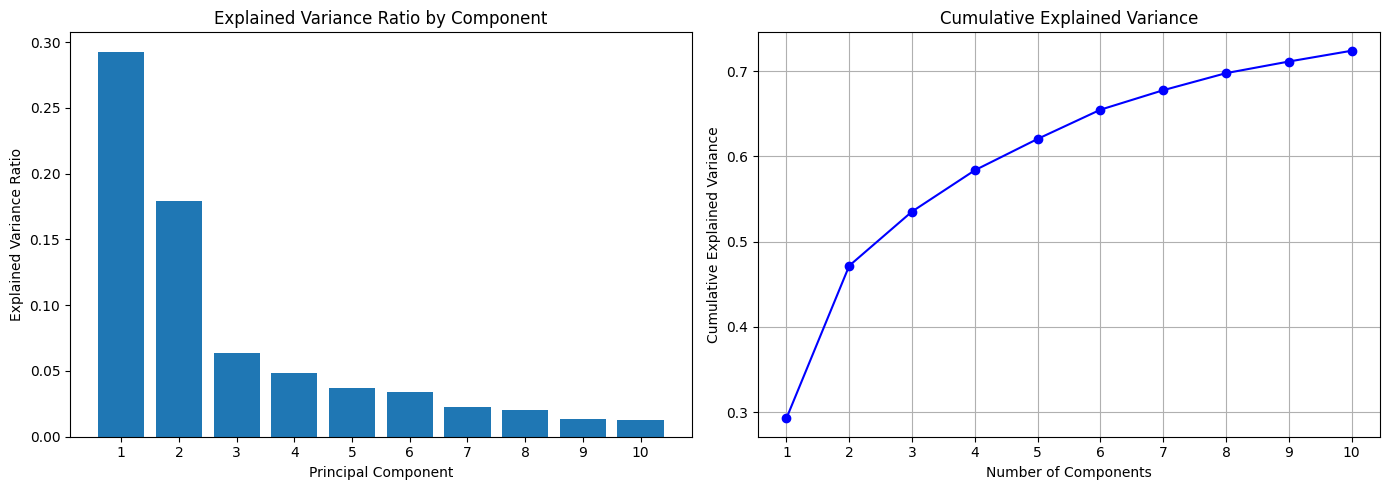

PCA variance plots saved as 'pca_variance.png'


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot explained variance ratio for first 10 components
pca_full = PCA(n_components=10)
pca_full.fit(X_normalized)

axes[0].bar(range(1, 11), pca_full.explained_variance_ratio_[:10])
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Explained Variance Ratio by Component')
axes[0].set_xticks(range(1, 11))

# Cumulative explained variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
axes[1].plot(range(1, 11), cumulative_variance[:10], 'bo-')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xticks(range(1, 11))
axes[1].grid(True)

plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()
print("PCA variance plots saved as 'pca_variance.png'")

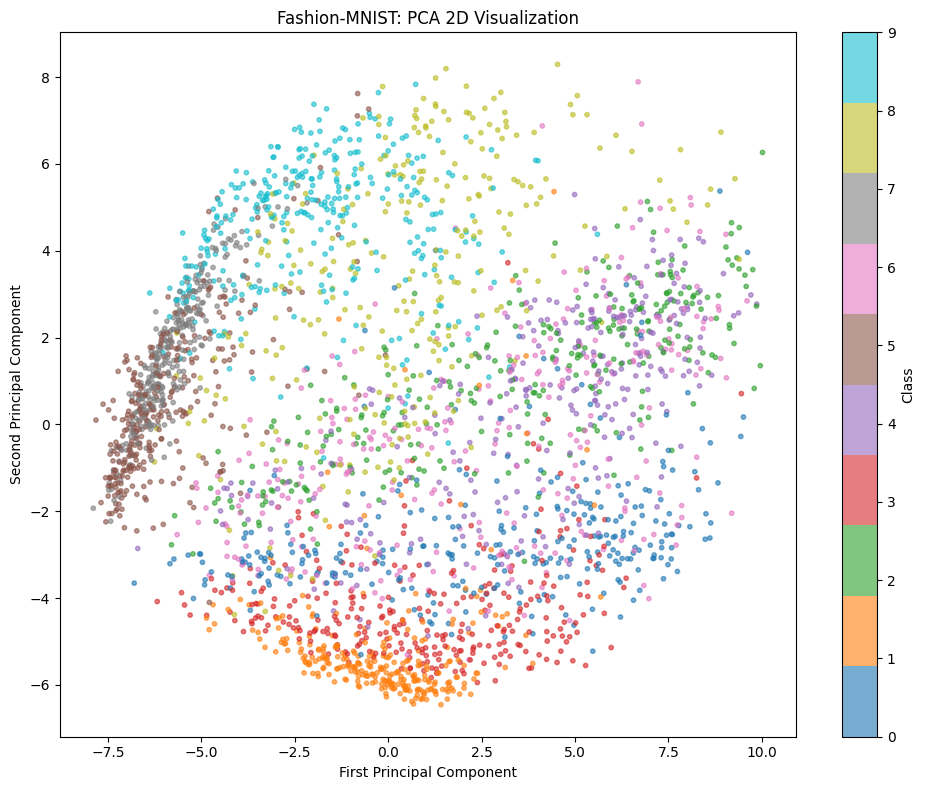

PCA visualization saved as 'pca_visualization.png'


In [11]:
# Visualize data in 2D PCA space
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', s=10, alpha=0.6)
ax.set_xlabel('First Principal Component')
ax.set_ylabel('Second Principal Component')
ax.set_title('Fashion-MNIST: PCA 2D Visualization')
plt.colorbar(scatter, ax=ax, label='Class')
plt.tight_layout()
plt.savefig('pca_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("PCA visualization saved as 'pca_visualization.png'")



Part C: t-SNE Implementation
Applying t-SNE with perplexity=5...
t-SNE (perp=5) computation time: 18.46 seconds
Applying t-SNE with perplexity=30...
t-SNE (perp=30) computation time: 15.08 seconds
Applying t-SNE with perplexity=50...
t-SNE (perp=50) computation time: 17.22 seconds


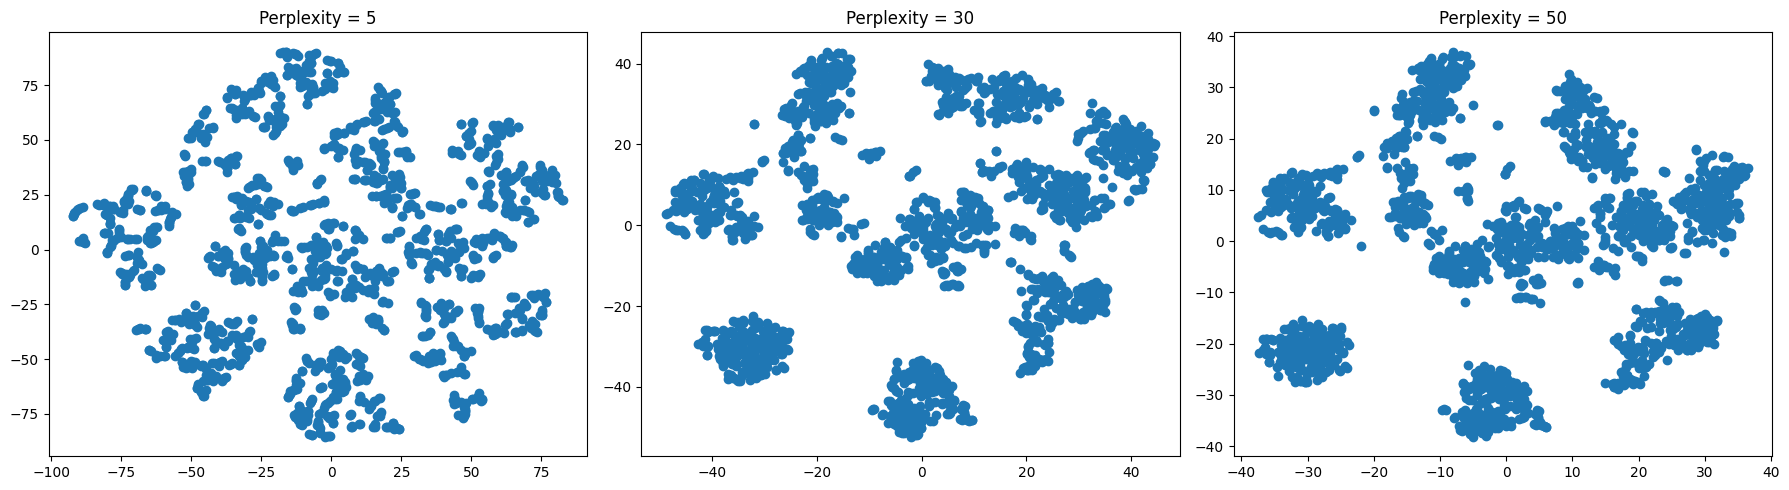

In [14]:
# Required imports
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Example dataset (replace with your dataset)
from sklearn.datasets import load_digits
X = load_digits().data

# Normalize data
X_normalized = StandardScaler().fit_transform(X)

# Define perplexity values
perplexities = [5, 30, 50]

# Part C: t-SNE Implementation
print("\n" + "=" * 50)
print("Part C: t-SNE Implementation")
print("=" * 50)

tsne_results = {}
tsne_times = {}

fig, axes = plt.subplots(1, len(perplexities), figsize=(18,5))

# Fix: handle case when only 1 perplexity
if len(perplexities) == 1:
    axes = [axes]

for i, perplexity in enumerate(perplexities):

    print(f"Applying t-SNE with perplexity={perplexity}...")

    start_time = time.time()

    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=42,
        max_iter=1000
    )

    X_tsne = tsne.fit_transform(X_normalized)

    tsne_time = time.time() - start_time

    tsne_results[perplexity] = X_tsne
    tsne_times[perplexity] = tsne_time

    print(f"t-SNE (perp={perplexity}) computation time: {tsne_time:.2f} seconds")

    # Plot results
    axes[i].scatter(X_tsne[:,0], X_tsne[:,1])
    axes[i].set_title(f"Perplexity = {perplexity}")

plt.tight_layout()
plt.show()

